In [47]:
import os
import xarray as xr
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import above_library.emulation as em
import above_library.parameter_generation as paramgen
import above_library.calibration as cal
import above_library.utils as utils
import above_library.plotting as plotting

import importlib

In [48]:
top_dir = '/glade/work/afoster/ABoVE'
param_dir = '/glade/work/afoster/ABoVE/parameter_files'
output_dir = os.path.join(top_dir, 'parameter_outputs')
lh_dir = os.path.join(param_dir, 'fates_lh_black_spruce')
hist_dir = os.path.join(top_dir, 'hist_outputs')
emulator_dir = os.path.join(top_dir, 'emulators')

config_dir = '/glade/work/afoster/ABoVE/calibration_configs'
config_file = os.path.join(config_dir, 'black_spruce.yaml')
ensemble_config = utils.get_config_file(config_file)

var_config_file = '/glade/work/afoster/ABoVE/model_vars.yaml'
var_config = utils.get_config_file(var_config_file)

fig_dir = '/glade/work/afoster/ABoVE/figures'

# default parameter file
fates_param_name = "fates_params_api40_nwt_update_agb.nc"
default_param_data = xr.open_dataset(os.path.join(param_dir, fates_param_name), decode_timedelta=False)

# excel file with information about parameters
param_list_name = "param_list_sci.1.81.1_api.38.0.0_nwt_jan2026.xls"
param_list_file = os.path.join(param_dir, param_list_name)
param_dat = paramgen.get_param_dictionary(param_list_file)

# Latin Hypercube key
lh_key_file = os.path.join(lh_dir, 'nwt_lh_key_jags.csv')
ensemble_tag = 'NWT_LH_'

# modeled data
model_dat = xr.open_dataset(os.path.join(hist_dir, 'black_spruce_ens.nc'))
lh_key = em.get_lh_key(lh_key_file, ensemble_tag,
                       np.unique(model_dat.ensemble.values))
param_names = lh_key.columns

jags_params = ['fates_leafn_vert_scaler_coeff1', 'fates_leafn_vert_scaler_coeff2']

obs = xr.open_dataset(ensemble_config['obs_df'])
obs_mean = obs.sel(type='mean')
obs_std = obs.sel(type='std')

pft = ensemble_config['pft']
calibration_vars = [f"{pft}_{variable}" for variable in ensemble_config['variables']]
calibration_labels = [var_config[variable]['long_name'] for variable in ensemble_config['variables']]
calibration_units = [var_config[variable]['units'] for variable in ensemble_config['variables']]

emulators = em.load_emulators(ensemble_config['emulator_dir'], calibration_vars, [])
targets = [obs_mean[v].values for v in ensemble_config['variables']]
sds = [obs_std[v].values for v in ensemble_config['variables']]

In [49]:
default_df = paramgen.get_default_normalized_param_values(param_names, param_dat, default_param_data, jags_params,
                                                          pft=1)
default_values = default_df.iloc[0]

/glade/work/afoster/ABoVE/above_library/parameter_generation.py:188: RuntimeWarning: invalid value encountered in divide
  return (value - min_value) / (max_value - min_value)
/glade/work/afoster/ABoVE/above_library/parameter_generation.py:188: RuntimeWarning: divide by zero encountered in divide
  return (value - min_value) / (max_value - min_value)


In [50]:
out_files = [os.path.join(output_dir, f) for f in sorted(os.listdir(output_dir)) if f.endswith('.csv')]
parameter_dfs = []
for file in out_files:
    parameter_dfs.append(pd.read_csv(file))
parameter_df = pd.concat(parameter_dfs, ignore_index=True).drop(columns=['run_id'])

In [51]:
metrics_df = cal.get_calibration_metrics(parameter_df, participation_threshold=0.5, iqr_threshold=0.5)
param_order = metrics_df["parameter"].tolist()
n_params = len(param_order)
n_converged = metrics_df["converged"].sum()
print(f"Converged: {n_converged} / {n_params} shown  "
      f"({metrics_df['converged'].mean()*100:.0f}%)")

Converged: 29 / 47 shown  (62%)


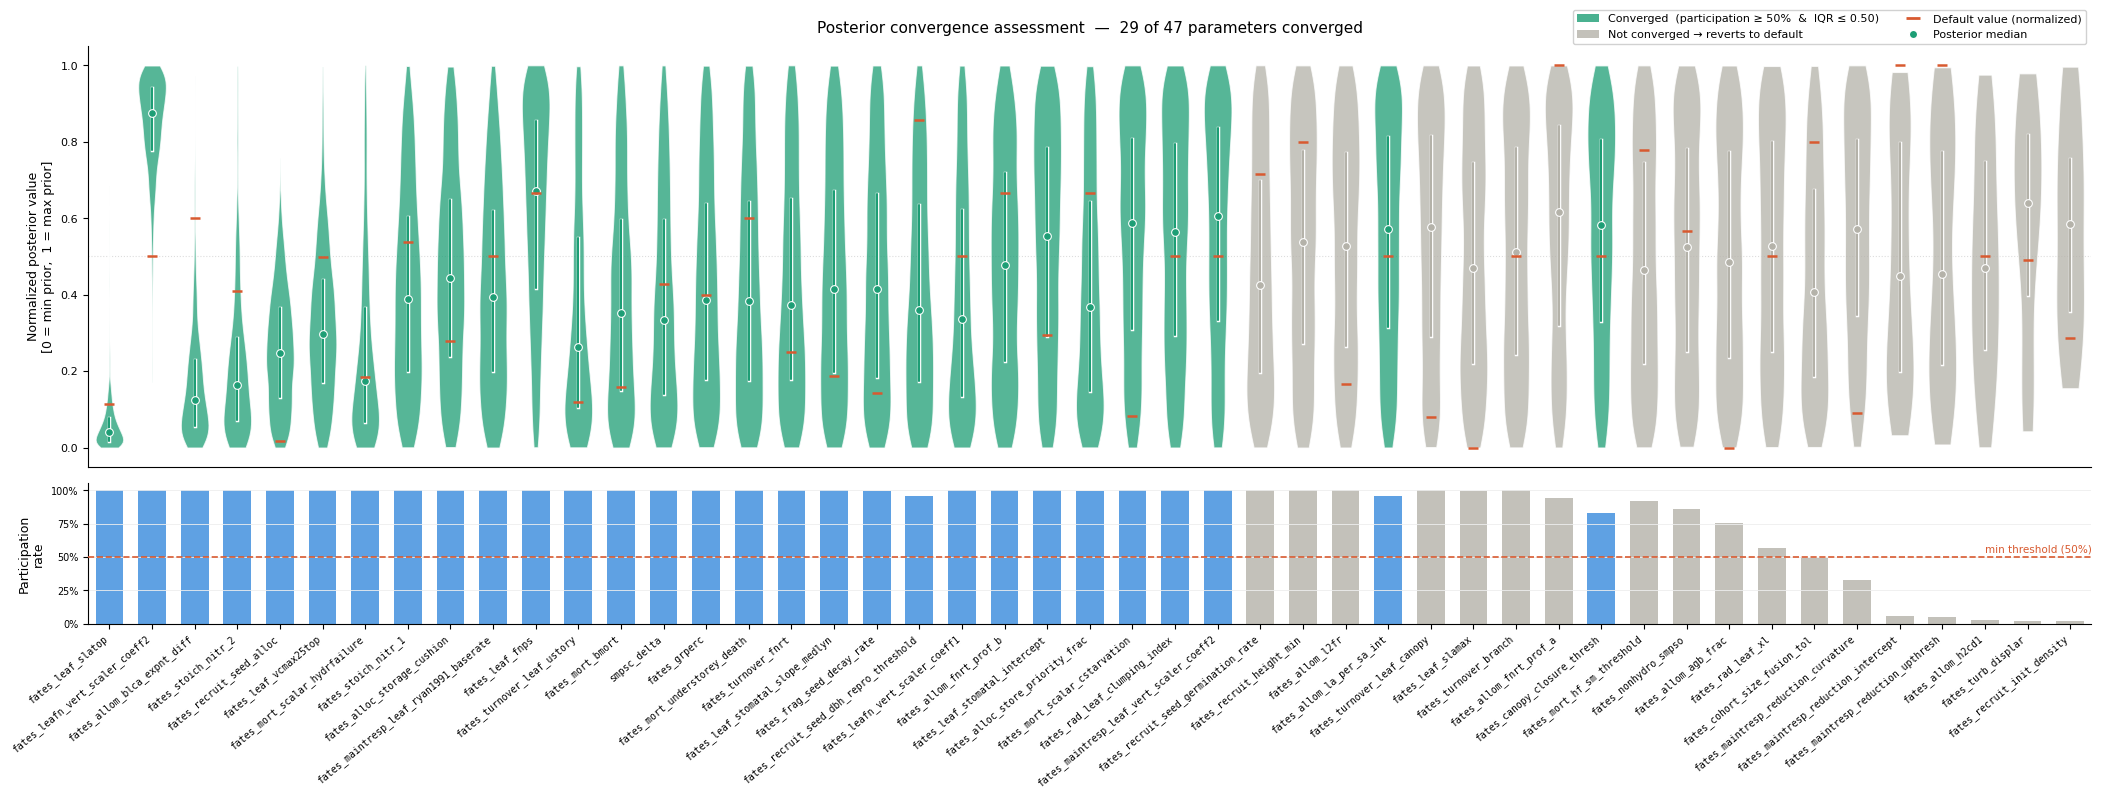

In [52]:
plotting.plot_posterior_df(parameter_df, metrics_df, default_values, participation_threshold=0.5,
                          iqr_threshold = 0.5)
plt.savefig(os.path.join(fig_dir, "posterior_df.png"), dpi=200, bbox_inches="tight")

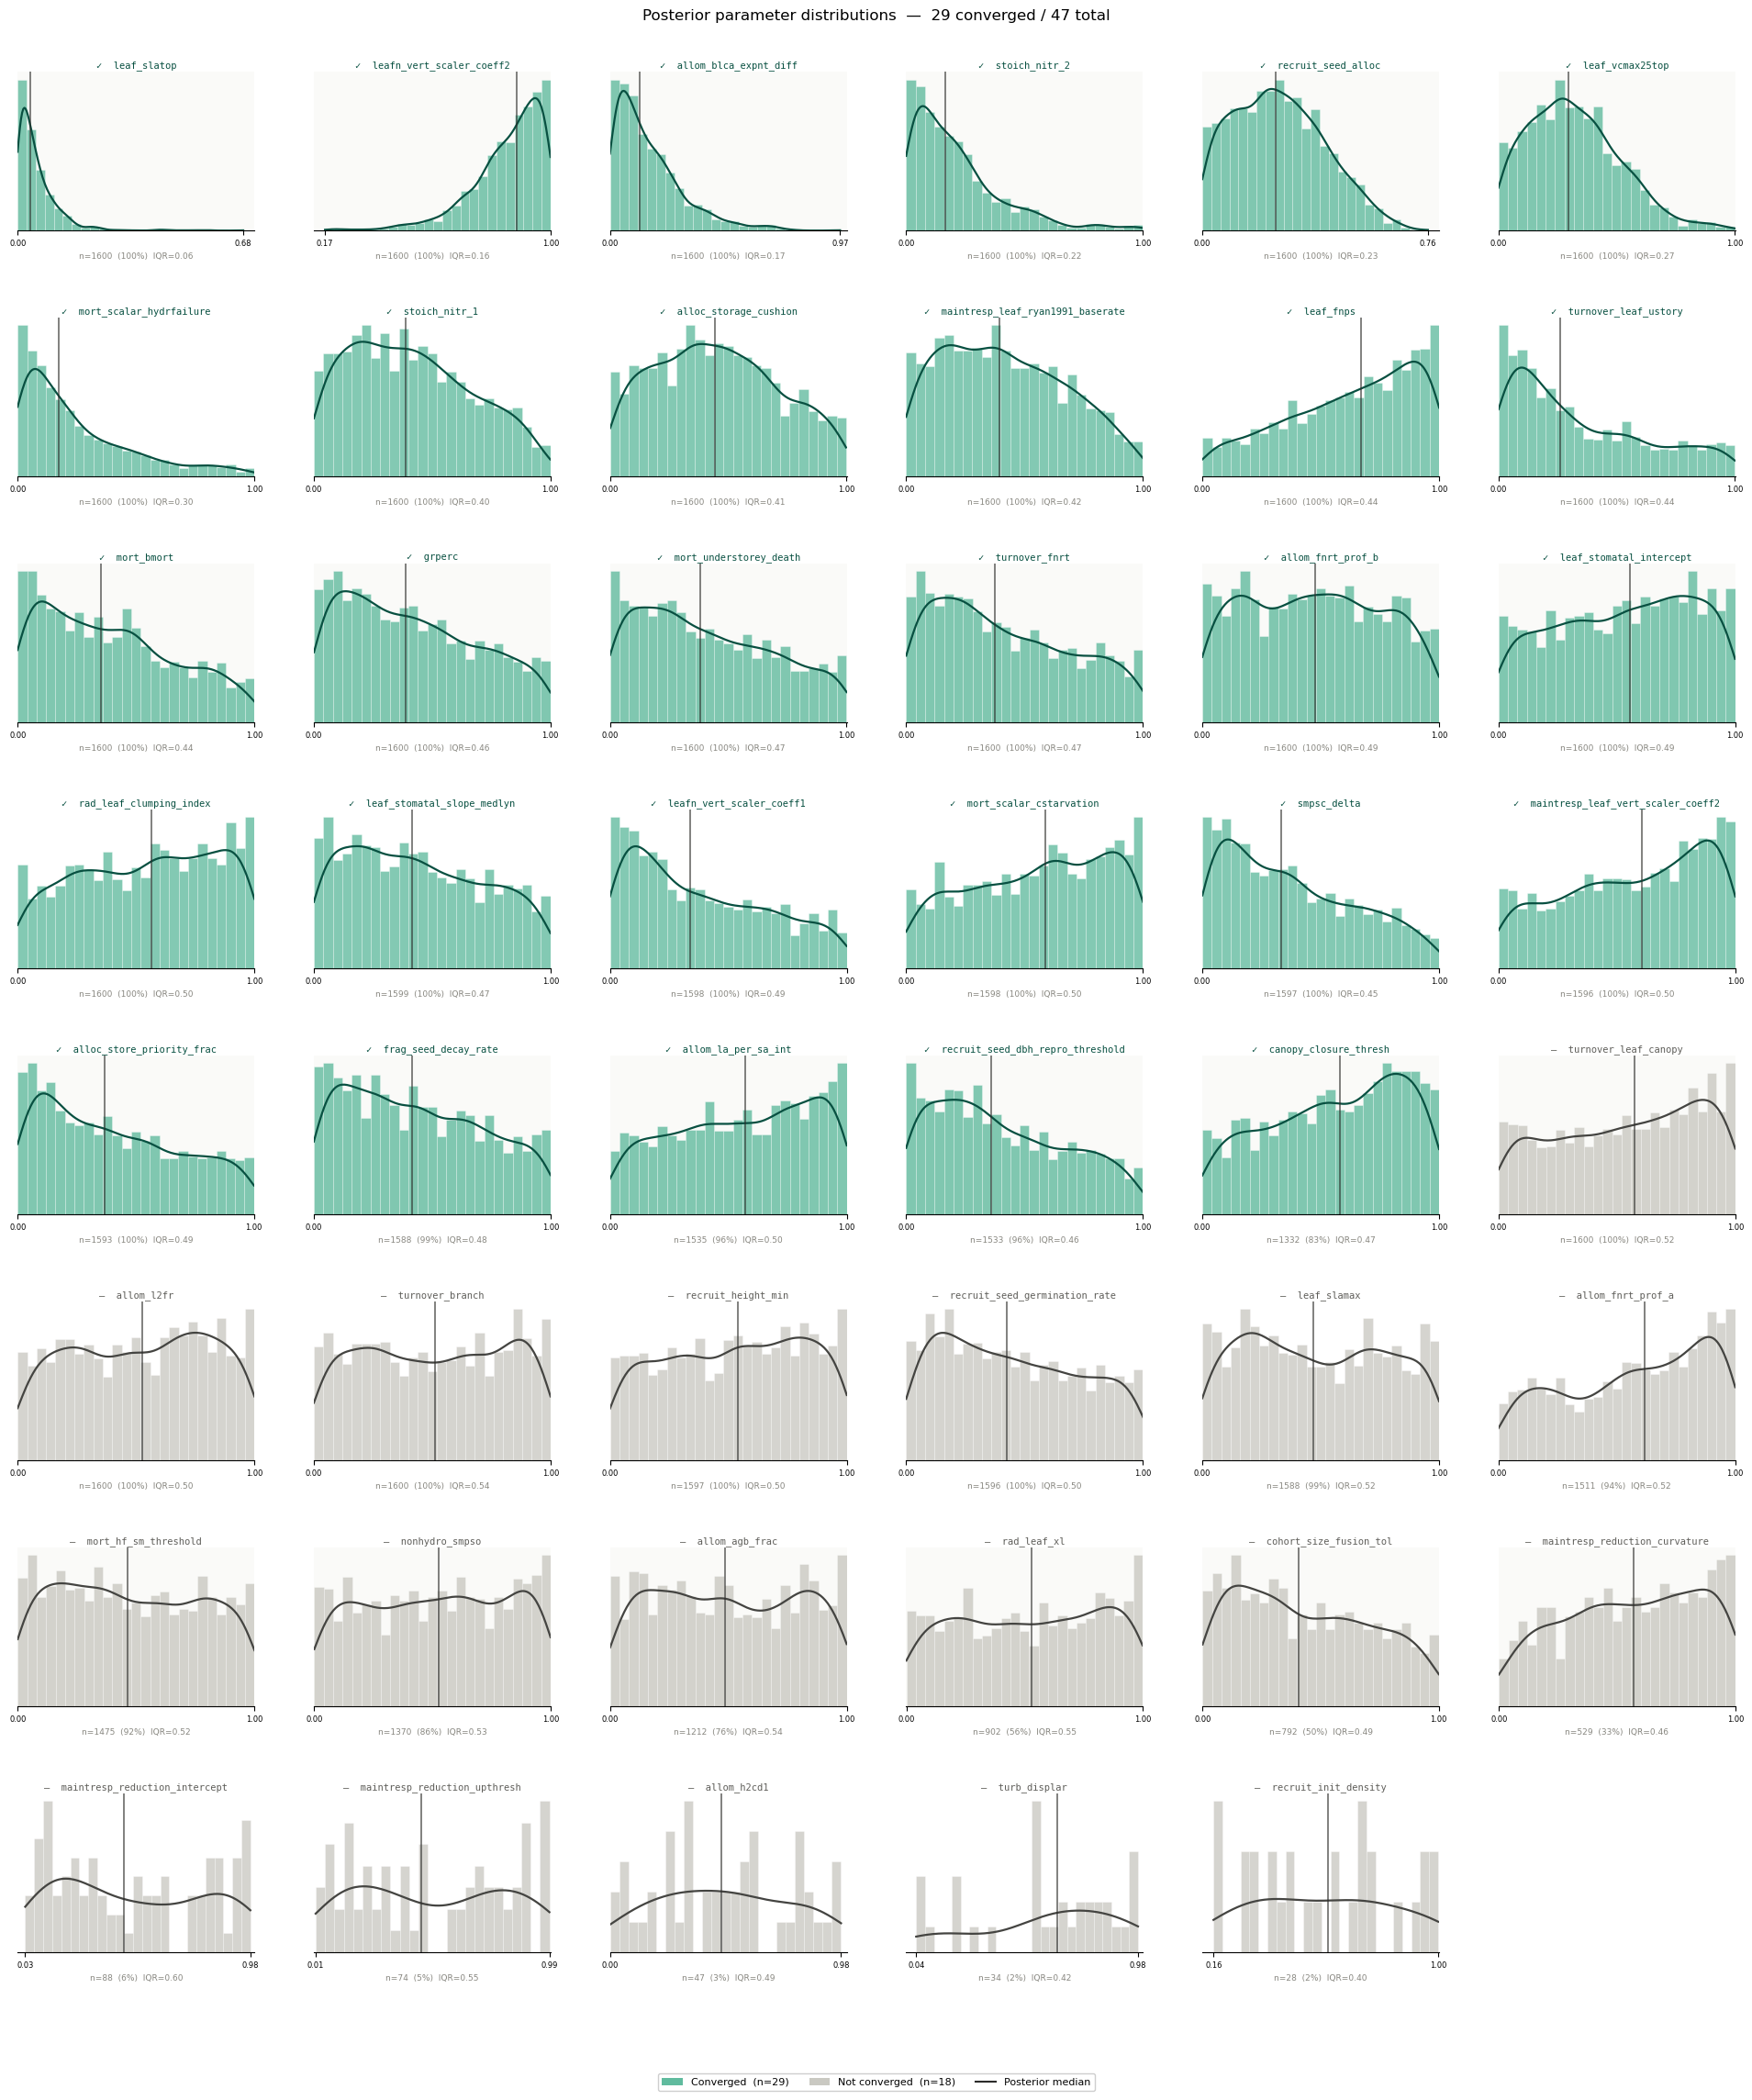

In [53]:
plotting.plot_parameter_histograms(parameter_df, metrics_df)
plt.savefig(os.path.join(fig_dir, "posterior_histograms.png"), dpi=200, bbox_inches="tight")

In [ ]:
params_in = metrics_df[metrics_df.participation > 0.5].parameter.values

In [ ]:
well_sampled = metrics_df[(metrics_df["participation"] >= 0.5)]["parameter"].tolist()
posterior_subset = parameter_df[well_sampled].dropna(how="all")

In [ ]:
corr = posterior_subset.corr(method="spearman", min_periods=20)

In [ ]:
corr_long = (corr
    .where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_long.columns = ["param_a", "param_b", "spearman_rho"]
corr_long["abs_rho"] = corr_long["spearman_rho"].abs()

In [ ]:
strong_pairs = (corr_long[corr_long["abs_rho"] >= 0.3]
                .sort_values("abs_rho", ascending=False))

In [ ]:
max_corr = corr.abs().where(
    np.tril(np.ones(corr.shape), k=-1).astype(bool)
).max()

metrics_df["max_corr_with_any"] = metrics_df["parameter"].map(
    lambda p: max_corr.get(p, np.nan)
)
metrics_df["correlated"] = metrics_df["max_corr_with_any"] >= 0.3

In [ ]:
params_in = metrics_df[(metrics_df["participation"] >= 0.5) & (metrics_df["converged"])]["parameter"].tolist()

In [ ]:
params_out = list(metrics_df[~metrics_df.parameter.isin(params_in)]["parameter"])

In [ ]:
params_out

In [ ]:
print(metrics_df[metrics_df["correlated"]][
    ["parameter", "participation", "iqr", "max_corr_with_any"]
].to_string(index=False))

In [ ]:
import seaborn as sns

In [ ]:
fig, ax = plt.subplots(figsize=(max(8, len(well_sampled) * 0.45),
                                max(7, len(well_sampled) * 0.45)))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # upper triangle only
sns.heatmap(
    corr,
    mask=mask,
    cmap="RdBu_r",
    vmin=-0.5, vmax=0.5,
    center=0,
    square=True,
    linewidths=0.4,
    linecolor="#eeeeee",
    annot=len(well_sampled) <= 15,   # only annotate if small enough to read
    fmt=".2f",
    ax=ax,
    cbar_kws={"shrink": 0.6, "label": "Spearman ρ"}
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right",
                   fontsize=7.5, fontfamily="monospace")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,
                   fontsize=7.5, fontfamily="monospace");
plt.tight_layout()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy.stats import gaussian_kde, spearmanr

def plot_posterior_joint(posterior_df, param_a, param_b,
                          color="#1D9E75", kde_color=None,
                          label_a=None, label_b=None):
    """
    Joint scatter plot with marginal KDE histograms.
    Shows posterior samples for two correlated parameters.
    
    Parameters
    ----------
    posterior_df : pd.DataFrame  — wide format posterior samples
    param_a, param_b : str       — column names to plot
    color : str                  — point/histogram color
    kde_color : str              — KDE line color (defaults to darker shade of color)
    label_a, label_b : str       — axis labels (defaults to param name sans 'fates_')
    """
    kde_color = kde_color or "#085041"
    label_a = label_a or param_a.replace("fates_", "")
    label_b = label_b or param_b.replace("fates_", "")

    plot_df = posterior_df[[param_a, param_b]].dropna()
    x = plot_df[param_a].values
    y = plot_df[param_b].values

    rho, pval = spearmanr(x, y)

    # ── Layout ────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(6.5, 6.5))
    gs  = gridspec.GridSpec(
        2, 2,
        width_ratios=[4, 1.2],
        height_ratios=[1.2, 4],
        hspace=0.05, wspace=0.05
    )
    ax_joint  = fig.add_subplot(gs[1, 0])
    ax_top    = fig.add_subplot(gs[0, 0], sharex=ax_joint)
    ax_right  = fig.add_subplot(gs[1, 1], sharey=ax_joint)

    # ── Joint scatter ─────────────────────────────────────────────────────────
    ax_joint.scatter(x, y, alpha=0.35, s=14, color=color,
                     edgecolors="none", zorder=2)

    # 2D KDE contours
    try:
        xy     = np.vstack([x, y])
        kde2d  = gaussian_kde(xy)
        xi     = np.linspace(x.min(), x.max(), 60)
        yi     = np.linspace(y.min(), y.max(), 60)
        Xi, Yi = np.meshgrid(xi, yi)
        Zi     = kde2d(np.vstack([Xi.ravel(), Yi.ravel()])).reshape(Xi.shape)
        ax_joint.contour(Xi, Yi, Zi, levels=5,
                         colors=kde_color, linewidths=0.8,
                         alpha=0.6, zorder=3)
    except Exception:
        pass   # skip contours if KDE fails (too few points)

    # Correlation annotation
    pval_str = f"p < 0.001" if pval < 0.001 else f"p = {pval:.3f}"
    ax_joint.text(
        0.04, 0.96,
        f"Spearman ρ = {rho:.3f}\n{pval_str}\nn = {len(x)}",
        transform=ax_joint.transAxes,
        fontsize=8.5, va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.35", fc="white",
                  ec="#cccccc", alpha=0.9)
    )

    ax_joint.set_xlabel(label_a, fontsize=9, fontfamily="monospace")
    ax_joint.set_ylabel(label_b, fontsize=9, fontfamily="monospace")
    ax_joint.spines[["top", "right"]].set_visible(False)
    ax_joint.tick_params(labelsize=8)

    # ── Top marginal (param_a) ────────────────────────────────────────────────
    ax_top.hist(x, bins=28, color=color, alpha=0.5,
                edgecolor="white", linewidth=0.4)
    kde_x  = gaussian_kde(x)
    xi_kde = np.linspace(x.min(), x.max(), 200)
    ax_top2 = ax_top.twinx()
    ax_top2.plot(xi_kde, kde_x(xi_kde), color=kde_color,
                 linewidth=1.5, zorder=3)
    ax_top2.set_yticks([])
    ax_top.axvline(np.median(x), color=kde_color, linewidth=1.2,
                   linestyle="--", alpha=0.7)
    ax_top.set_ylabel("Count", fontsize=8)
    ax_top.spines[["top", "right"]].set_visible(False)
    ax_top.tick_params(labelbottom=False, labelsize=7)

    # ── Right marginal (param_b) ──────────────────────────────────────────────
    ax_right.hist(y, bins=28, color=color, alpha=0.5,
                  edgecolor="white", linewidth=0.4,
                  orientation="horizontal")
    kde_y  = gaussian_kde(y)
    yi_kde = np.linspace(y.min(), y.max(), 200)
    ax_right2 = ax_right.twinx()
    ax_right2.plot(kde_y(yi_kde), yi_kde, color=kde_color,
                   linewidth=1.5, zorder=3)
    ax_right2.set_yticks([])
    ax_right.axhline(np.median(y), color=kde_color, linewidth=1.2,
                     linestyle="--", alpha=0.7)
    ax_right.set_xlabel("Count", fontsize=8)
    ax_right.spines[["top", "right"]].set_visible(False)
    ax_right.tick_params(labelleft=False, labelsize=7)

    fig.suptitle("Posterior joint distribution", fontsize=11,
                 fontweight="500", y=0.98)

    plt.savefig("posterior_joint.pdf", dpi=300, bbox_inches="tight")
    plt.savefig("posterior_joint.png", dpi=200, bbox_inches="tight")
    


# Usage — plug in your two most correlated parameters from strong_pairs
plot_posterior_joint(
    parameter_df,
    param_a="fates_leaf_vcmax25top",
    param_b="fates_leaf_slatop",
    color="#1D9E75",
)

In [ ]:
gpp_em = em.load_emulators(emulator_dir, ['black_spruce_GPP'], [])

In [ ]:
full_param_df = parameter_df.reindex(columns=lh_key.columns)
final_sample = full_param_df.fillna(dict(default_values))

In [ ]:
gpp_pred, gpp_var = em.chunked_emulation(gpp_em[0], final_sample)

In [ ]:
gpp_min = 0.5
gpp_max = 0.95

# 3. Filter the parameter sets
constrained_sample = final_sample[
    (gpp_pred >= gpp_min) & 
    (gpp_pred <= gpp_max)
].copy().reset_index(drop=True)

gpp_sample, _ = em.chunked_emulation(gpp_em[0], constrained_sample)
constrained_sample['gpp_pred'] = gpp_sample

In [ ]:
for i, emulator in enumerate(emulators):
    y_pred, y_var = em.chunked_emulation(emulator, constrained_sample)
    constrained_sample[f"{calibration_vars[i]}_pred"] = y_pred
    implaus = em.implausibility_metric(y_pred, targets[i], y_var, sds[i] ** 2)
    constrained_sample[f"{calibration_vars[i]}_implaus"] = implaus

In [ ]:
constrained_sample["implaus_sum"] = em.calculate_implaus_sum(
    constrained_sample, [f"{var}_implaus" for var in calibration_vars]
)

In [ ]:
best_sample_index = constrained_sample[["implaus_sum"]].idxmin()
best_sample = constrained_sample.loc[best_sample_index, :]

In [ ]:
params_to_choose = ['fates_leaf_slatop', 'fates_leaf_vcmax25top', 'fates_mort_bmort',
                    'fates_recruit_seed_alloc', 'fates_leafn_vert_scaler_coeff1',
                    'fates_allom_blca_expnt_diff']

df_subset = constrained_sample[param_names]
final_par_list = []
for parameter in params_to_choose:
    final_par_list.append(cal.get_final_params(parameter, constrained_sample).to_frame().T)

In [ ]:
calibration_vars

In [ ]:
extremes_gpp_high = constrained_sample.nlargest(5, 'gpp_pred')
extremes_gpp_low = constrained_sample.nsmallest(5, 'gpp_pred')

extremes_basal_high = constrained_sample.nlargest(5, 'black_spruce_basal_area_pred')
extremes_basal_low = constrained_sample.nsmallest(5, 'black_spruce_basal_area_pred')

extremes_height_high = constrained_sample.nlargest(5, 'black_spruce_height_pred')
extremes_height_low = constrained_sample.nsmallest(5, 'black_spruce_height_pred')

In [ ]:
final_par_list.extend([best_sample, extremes_gpp_high, extremes_gpp_low, extremes_basal_high, extremes_basal_low,
                          extremes_height_high, extremes_height_low])

In [ ]:
validation_df = pd.concat(final_par_list)
validation_df = validation_df.drop_duplicates()
validation_df = validation_df[param_names]

In [ ]:
all_rescaled = {}
for parameter in param_names:
    if parameter in validation_df.columns:
        if parameter not in jags_params:
            val = validation_df[parameter].values
            norm_values = paramgen.get_rescaled_values(param_dat, val, default_param_data, parameter, 1)
            all_rescaled[parameter] = norm_values
        else:
            all_rescaled[parameter] = val
df = pd.DataFrame(all_rescaled)
df['fates_nonhydro_smpsc'] = df['fates_nonhydro_smpso'] + df['smpsc_delta']
df = df.drop(columns=['smpsc_delta'])

In [ ]:
def create_param_from_df(
    df: pd.DataFrame, default_param_data: xr.Dataset, pft: int) -> xr.Dataset:
    """Creates a new FATES parameter file from an input default parameter and a data frame
    with parameter values to update

    Args:
        df (pd.DataFrame): input data frame with parameter names and values to update
        default_param_data (xr.Dataset): default parameter set
    Returns:
        xr.Dataset: new parameter file
    """

    # copy new parameter file
    new_param = default_param_data.copy(deep=False)

    # loop through all parameters and update
    params = sorted(np.unique(df.parameter.values))
    for param in params:
        sub = df[df.parameter == param]

        default_val = new_param[param].values
        new_val = default_val
        new_val[0, pft - 1] = round(sub, 3)
        new_param[param].values = new_val

    return new_param

In [ ]:
df.to_csv('black_spruce_output.csv')

In [ ]:
pft = 1

In [ ]:
def make_new_param(df_row, index, out_dir, file_tag):
    
    new_param = default_param_data.copy(deep=False)
    params = sorted(np.unique(df_row.parameter.values))
    for param in params:
        sub = df_row[df_row.parameter == param]
        sub_val = sub['parameter_value'].values[0]
        
        if param in ['fates_stoich_nitr_1', 'fates_stoich_nitr_2']:
            actual_param_name = 'fates_stoich_nitr'
        else:
            actual_param_name = param
        
        default_val = new_param[actual_param_name].values
        dims = new_param[actual_param_name].dims
    
        new_val = default_val
        if param == 'fates_stoich_nitr_1':
            new_val[0, pft] = round(sub_val, 3)
        elif param == 'fates_stoich_nitr_1':
            new_val[1, pft] = round(sub_val, 3)
        elif 'fates_leafage_class' in dims:
            new_val[0, pft] = round(sub_val, 3)
        elif len(dims) == 0:
            new_val = round(sub_val, 3)
        else:
            new_val[pft] = round(sub_val, 3)
    
        new_param[actual_param_name].values = new_val

    new_param.to_netcdf(os.path.join(out_dir, f'{file_tag}_{str(index).zfill(3)}.nc'))

In [ ]:
for i in range(len(df)):
    row = pd.DataFrame({'parameter_value': df.iloc[i]})
    row['parameter'] = row.index
    row = row.reset_index()
    make_new_param(row, i, '/glade/work/afoster/ABoVE/parameter_files/fates_black_spruce_val', 'FATES_BS')

In [ ]:
file_tag = 'FATES_BS'
ensembles = []
for i in range(len(df)):
    ensembles.append(f'{file_tag}_{str(i).zfill(3)}')

In [ ]:
file_path = '/glade/work/afoster/ABoVE/parameter_files/fates_black_spruce_val/param_files.txt'
with open(file_path, 'w') as file:
    for item in ensembles:
        file.write(f"{item}\n")